In [1]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# Import library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import library Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Mengunci Random Seed untuk Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
print("Setup selesai dan Random Seed telah dikunci ke-42.")

Setup selesai dan Random Seed telah dikunci ke-42.


Jumlah data training: 891 baris


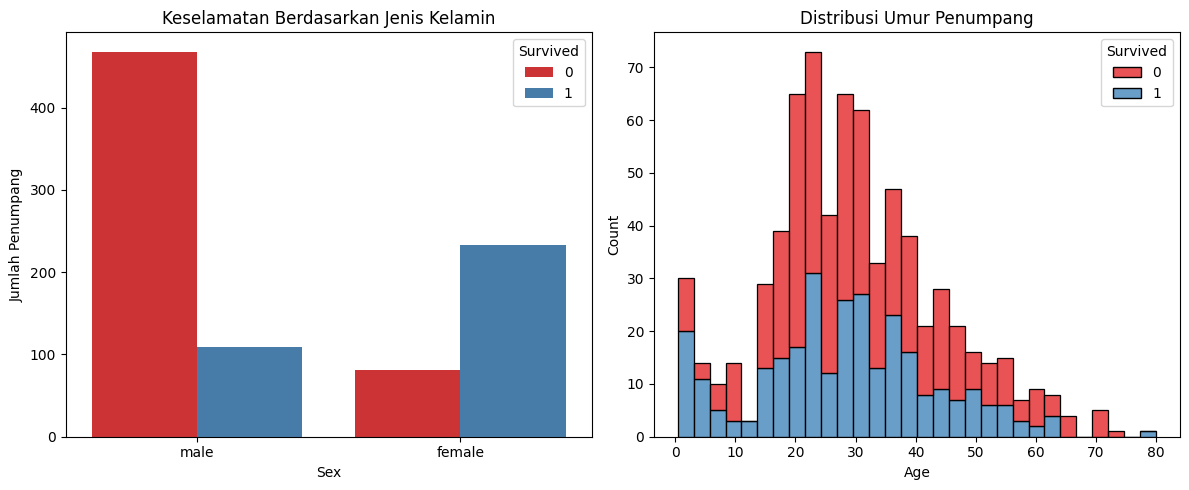

In [2]:
# Load dataset
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Menyimpan PassengerId untuk submission nanti
test_passenger_id = test_df['PassengerId']

print(f"Jumlah data training: {train_df.shape[0]} baris")

# --- EDA (Exploratory Data Analysis) ---
plt.figure(figsize=(12, 5))

# Grafik 1: Keselamatan berdasarkan Jenis Kelamin
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='Sex', hue='Survived', palette='Set1')
plt.title('Keselamatan Berdasarkan Jenis Kelamin')
plt.ylabel('Jumlah Penumpang')

# Grafik 2: Distribusi Umur Penumpang (Selamat vs Tidak)
plt.subplot(1, 2, 2)
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', bins=30, palette='Set1')
plt.title('Distribusi Umur Penumpang')

plt.tight_layout()
plt.show()

In [3]:
# Menggabungkan data sementara untuk preprocessing yang konsisten
df_all = pd.concat([train_df.drop('Survived', axis=1), test_df], axis=0).reset_index(drop=True)

# 1. Ekstraksi Gelar (Title) dari Nama (Tambahkan 'r' di depan string regex)
df_all['Title'] = df_all['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df_all['Title'] = df_all['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr',
                                           'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df_all['Title'] = df_all['Title'].replace('Mlle', 'Miss')
df_all['Title'] = df_all['Title'].replace('Ms', 'Miss')
df_all['Title'] = df_all['Title'].replace('Mme', 'Mrs')

# 2. Family Size (Ukuran Keluarga)
df_all['FamilySize'] = df_all['SibSp'] + df_all['Parch'] + 1

# 3. Imputasi Missing Values
df_all['Age'] = df_all['Age'].fillna(df_all.groupby('Title')['Age'].transform('median'))
df_all['Fare'] = df_all['Fare'].fillna(df_all['Fare'].median())
df_all['Embarked'] = df_all['Embarked'].fillna(df_all['Embarked'].mode()[0])

# 4. Binning Usia
df_all['Age_Bin'] = pd.cut(df_all['Age'], bins=[0, 12, 20, 40, 60, 120],
                           labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

# 5. Drop kolom yang tidak perlu (Termasuk Age asli karena sudah ada Age_Bin)
df_all = df_all.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age'], axis=1)

# 6. Categorical Encoding
# Label Encoding untuk Sex
label_encoder = LabelEncoder()
df_all['Sex'] = label_encoder.fit_transform(df_all['Sex'])

# One-Hot Encoding untuk Embarked, Title, dan Age_Bin
# (Lakukan ini HANYA SEKALI saja)
df_all = pd.get_dummies(df_all, columns=['Embarked', 'Title', 'Age_Bin'], drop_first=True)

# 7. Memisahkan kembali Train dan Test
X_train_full = df_all.iloc[:len(train_df), :]
X_test_final = df_all.iloc[len(train_df):, :]
y_train_full = train_df['Survived']

print("Fitur yang digunakan:", X_train_full.columns.tolist())

Fitur yang digunakan: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Age_Bin_Teen', 'Age_Bin_Adult', 'Age_Bin_Middle', 'Age_Bin_Senior']


In [4]:
# Split 80% Training, 20% Validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Normalisasi Data (Sangat penting untuk Deep Learning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print(f"Data latih: {X_train_scaled.shape[0]} sampel")
print(f"Data validasi: {X_val_scaled.shape[0]} sampel")

Data latih: 712 sampel
Data validasi: 179 sampel


In [5]:
from sklearn.linear_model import LogisticRegression

# --- Model 1: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_val_scaled)
rf_accuracy = accuracy_score(y_val, rf_preds)

print("=== Hasil Random Forest ===")
print(f"Akurasi Validasi: {rf_accuracy * 100:.2f}%\n")

# --- Model 2: Logistic Regression ---
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train_scaled, y_train)
logreg_preds = logreg_model.predict(X_val_scaled)
logreg_accuracy = accuracy_score(y_val, logreg_preds)

print("=== Hasil Logistic Regression ===")
print(f"Akurasi Validasi: {logreg_accuracy * 100:.2f}%")

=== Hasil Random Forest ===
Akurasi Validasi: 81.01%

=== Hasil Logistic Regression ===
Akurasi Validasi: 81.56%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Memulai Training MLP...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

=== Hasil Deep Learning (MLP) ===
Akurasi Validasi: 81.01%


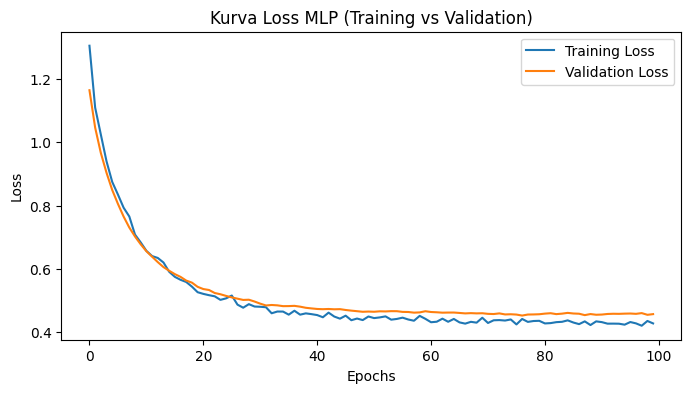

In [6]:
# Desain Arsitektur MLP
mlp_model = Sequential([
    # Hidden Layer 1 (dengan L2 Regularization agar tidak overfit)
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.01)),
    Dropout(0.3), # Dropout untuk matikan 30% neuron secara acak

    # Hidden Layer 2
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),

    # Output Layer (1 Neuron, Sigmoid untuk klasifikasi biner 0 atau 1)
    Dense(1, activation='sigmoid')
])

# Compile model
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training Model
print("Memulai Training MLP...")
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=0 # Ubah ke 1 jika ingin melihat proses tiap epoch
)

# Prediksi dan Evaluasi
mlp_preds_prob = mlp_model.predict(X_val_scaled)
mlp_preds = (mlp_preds_prob > 0.5).astype(int).flatten() # Ubah probabilitas jadi 0 atau 1
mlp_accuracy = accuracy_score(y_val, mlp_preds)

print("\n=== Hasil Deep Learning (MLP) ===")
print(f"Akurasi Validasi: {mlp_accuracy * 100:.2f}%")

# Plot kurva loss untuk melihat apakah terjadi overfitting
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kurva Loss MLP (Training vs Validation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
# Pilih model yang akurasinya lebih tinggi untuk submission (Misal kita pakai Random Forest)
# Lakukan prediksi pada data test Kaggle
final_predictions = rf_model.predict(X_test_scaled)

# Buat dataframe sesuai format Kaggle
submission = pd.DataFrame({
    "PassengerId": test_passenger_id,
    "Survived": final_predictions
})

# Simpan ke CSV
submission.to_csv('submission_titanic_kasus1.csv', index=False)
print("File 'submission_titanic_kasus1.csv' berhasil dibuat! Silakan unduh dari folder di sebelah kiri dan upload ke Kaggle.")

File 'submission_titanic_kasus1.csv' berhasil dibuat! Silakan unduh dari folder di sebelah kiri dan upload ke Kaggle.
